<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_2_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

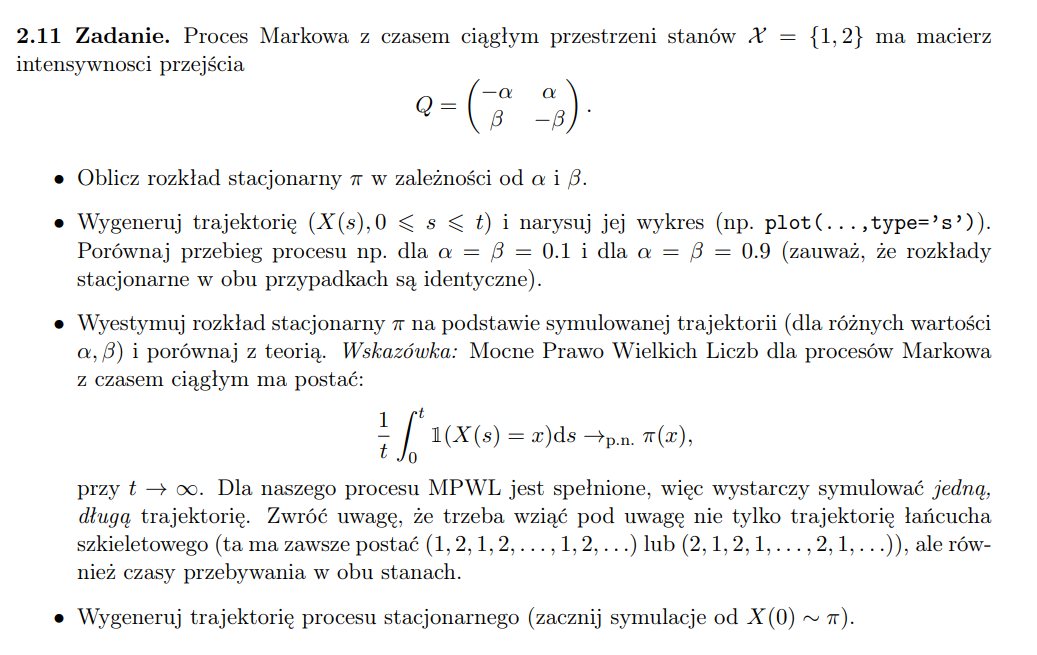

### Stationary distribution
---
Let us use the formula for stationary distribution with the intensity matrix:

$$\pi Q = [0, 0]$$

$$[\pi_1, \pi_2] \begin{pmatrix} -\alpha & \alpha \\ \beta & -\beta \end{pmatrix} = [0, \ 0]$$

$$-\alpha \pi_1 + \beta \pi_2 = 0 \implies \alpha \pi_1 = \beta \pi_2$$

Since $\pi_1 + \pi_2 = 1$, then:

$$\alpha \pi_1 = \beta (1 - \pi_1)$$
$$\alpha \pi_1 + \beta \pi_1 = \beta$$
$$\pi_1(\alpha + \beta) = \beta \implies \pi_1 = \frac{\beta}{\alpha + \beta}$$
$$\pi_2 = 1 - \pi_1 = \frac{\alpha}{\alpha + \beta}$$
$$\pi = \left[ \frac{\beta}{\alpha + \beta}, \frac{\alpha}{\alpha + \beta} \right]$$

### Simulations
---

#### Simulating trajectory
---

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sampler(T_max=100, alpha=0.1, beta=0.1, x0=1):
  t = [0]
  traj = [x0]

  while t[-1] < T_max:
    if traj[-1] == 1:
      t_prop = t[-1] + np.random.exponential(scale=1/alpha)
    else:
      t_prop = t[-1] + np.random.exponential(scale=1/beta)
    if t_prop <= T_max:
      t.append(t_prop)
      if traj[-1] == 1:
        traj.append(2)
      else:
        traj.append(1)
    else:
      t.append(T_max)
      traj.append(traj[-1])
      break

  return t, traj

In [4]:
t_01, traj_01 = sampler()
t_09, traj_09 = sampler(alpha=0.9, beta=0.9)

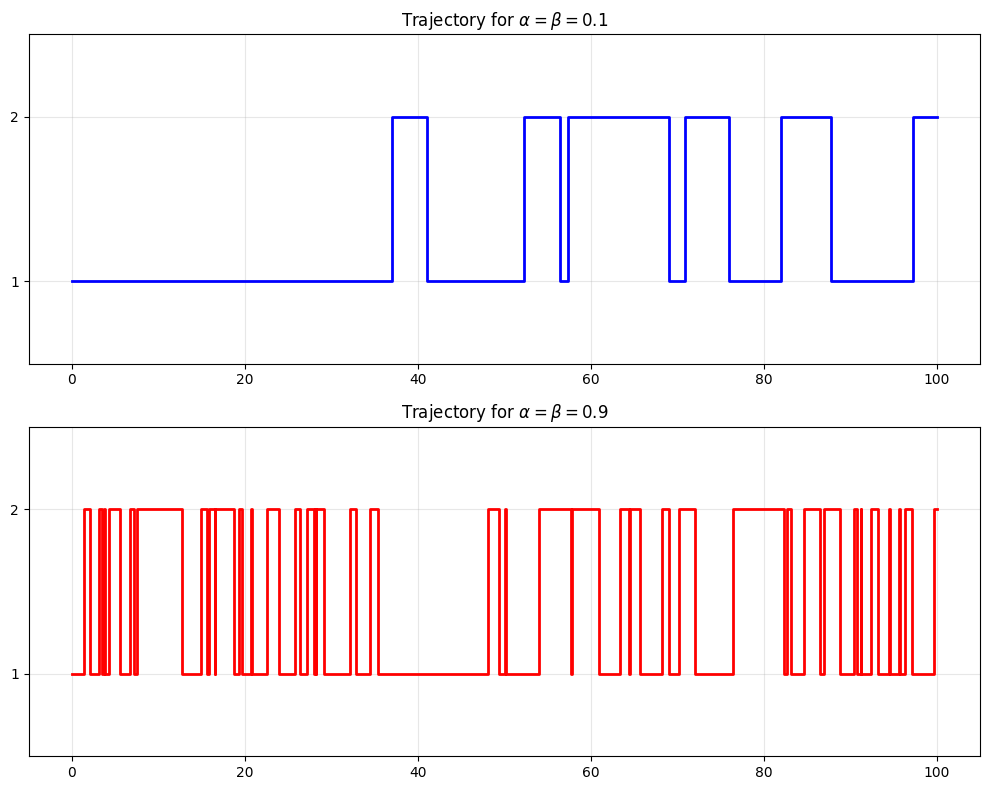

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# alpha = beta = 0.1
ax1.step(t_01, traj_01, where='post', color='blue', linewidth=2)
ax1.set_title(r"Trajectory for $\alpha = \beta = 0.1$")
ax1.set_yticks([1, 2])
ax1.set_ylim(0.5, 2.5)
ax1.grid(True, alpha=0.3)

# alpha = beta = 0.9
ax2.step(t_09, traj_09, where='post', color='red', linewidth=2)
ax2.set_title(r"Trajectory for $\alpha = \beta = 0.9$")
ax2.set_yticks([1, 2])
ax2.set_ylim(0.5, 2.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Estimating stationary distribution

In [8]:
alpha = 0.2
beta = 0.8
T_max = 100000

t_long, traj_long = sampler(T_max, alpha, beta)
t_long = np.array(t_long)
traj_long = np.array(traj_long)

holding_times = np.diff(t_long)
states_visited = traj_long[:-1]

time_in_1 = np.sum(holding_times[states_visited == 1])
time_in_2 = np.sum(holding_times[states_visited == 2])

pi_1_est = time_in_1 / T_max
pi_2_est = time_in_2 / T_max

pi_1_th = beta / (alpha + beta)
pi_2_th = alpha / (alpha + beta)

print(f"Estimation for = {alpha}, beta = {beta}")
print(f"Theory:     pi_1 = {pi_1_th:.4f}, pi_2 = {pi_2_th:.4f}")
print(f"Estimation:  pi_1 = {pi_1_est:.4f}, pi_2 = {pi_2_est:.4f}")

Estimation for = 0.2, beta = 0.8
Theory:     pi_1 = 0.8000, pi_2 = 0.2000
Estimation:  pi_1 = 0.8024, pi_2 = 0.1976


#### Trajectory of stationary process
---

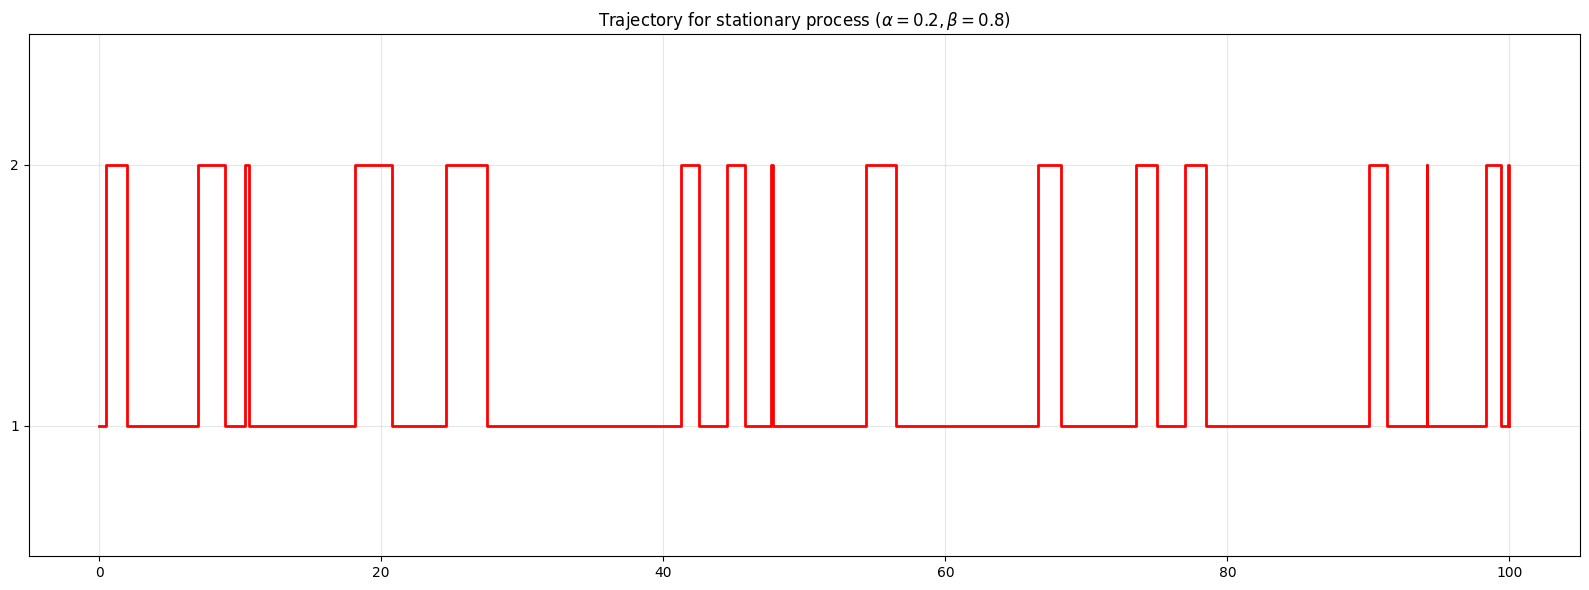

In [11]:
x0 = np.random.choice([1, 2], p=[pi_1_th, pi_2_th])
t_stat, traj_stat = sampler(T_max=100, alpha=alpha, beta=beta, x0=x0)

plt.figure(figsize=(16, 6))
plt.step(t_stat, traj_stat, where='post', color='red', linewidth=2)
plt.title(r"Trajectory for stationary process ($\alpha = 0.2, \beta = 0.8)$")
plt.yticks([1, 2])
plt.ylim(0.5, 2.5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()